In [1]:
%load_ext autoreload
%autoreload 2

# Get max curated data

In [2]:
import requests
from yaml import safe_load
import numpy as np
import re

activities = ["Ki", "IC50"]
data_url = "https://raw.githubusercontent.com/rinikerlab/overlapping_assays/refs/heads/main/datasets/{dataset}_datasets.yaml"


command_str = (
    "getchembl -tids {targets} -chiral -duchi -reqdoc "
    "-cae --max-assay-size 100 --min-assay-size 20 -smr -kfd -calc -c 9 -sd "
    "-biotype {activity} -reqdoc"  # -idcols assay_type
)

## Ki

In [3]:
result = requests.get(data_url.format(dataset=activities[0]))
result.raise_for_status()

datasets = safe_load(result.content)

ki_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ki_targets.append(datasets["sources"][key]["description"])

ki_targets = np.unique(ki_targets).tolist()
ki_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ki_targets]
command = command_str.format(targets=" ".join(ki_targets), activity=activities[0])
print(command)

getchembl -tids CHEMBL205 CHEMBL214 CHEMBL217 CHEMBL218 CHEMBL224 CHEMBL226 CHEMBL228 CHEMBL233 CHEMBL234 CHEMBL237 CHEMBL243 CHEMBL244 CHEMBL251 CHEMBL253 CHEMBL255 CHEMBL256 CHEMBL259 CHEMBL261 CHEMBL264 CHEMBL313 CHEMBL3155 CHEMBL3242 CHEMBL3371 CHEMBL344 CHEMBL3594 CHEMBL4153 -chiral -duchi -reqdoc -cae --max-assay-size 100 --min-assay-size 20 -smr -kfd -calc -c 9 -sd -biotype Ki -reqdoc


## IC50

In [4]:
result = requests.get(data_url.format(dataset=activities[1]))
result.raise_for_status()

datasets = safe_load(result.content)

ic50_targets = []
keys = datasets["sources"].keys()
for key in keys:
    ic50_targets.append(datasets["sources"][key]["description"])

ic50_targets = np.unique(ic50_targets).tolist()
ic50_targets = [re.compile("(CHEMBL\d+)").search(t).group(1) for t in ic50_targets]
command = command_str.format(targets=" ".join(ic50_targets), activity=activities[1])
print(command)

getchembl -tids CHEMBL1163125 CHEMBL1741186 CHEMBL1865 CHEMBL1974 CHEMBL2039 CHEMBL203 CHEMBL206 CHEMBL2148 CHEMBL220 CHEMBL222 CHEMBL228 CHEMBL2409 CHEMBL240 CHEMBL243 CHEMBL247 CHEMBL260 CHEMBL262 CHEMBL279 CHEMBL284 CHEMBL2971 CHEMBL3105 CHEMBL3130 CHEMBL3229 CHEMBL325 CHEMBL3267 CHEMBL344 CHEMBL3471 CHEMBL3717 CHEMBL4005 CHEMBL4015 CHEMBL4078 CHEMBL4235 CHEMBL4296 CHEMBL4685 CHEMBL4794 CHEMBL4822 CHEMBL5145 CHEMBL5251 CHEMBL5763 -chiral -duchi -reqdoc -cae --max-assay-size 100 --min-assay-size 20 -smr -kfd -calc -c 9 -sd -biotype IC50 -reqdoc


<Axes: >

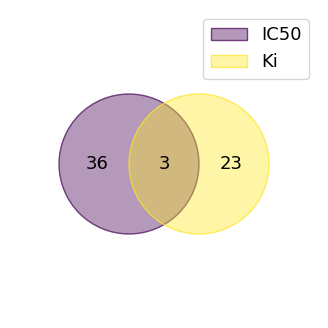

In [5]:
from venn import venn

venn_dict = {"IC50": set(ic50_targets), "Ki": set(ki_targets)}
venn(venn_dict, figsize=(4, 4))

# IC50 overlap

In [6]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
from scipy import stats  # For Spearman R and Kendall Tau
from sklearn.metrics import r2_score

In [7]:
df = pd.read_csv("../example/max_curated_example/IC50-further-filtered/chembl_data.csv")
subset = df.query('original_smiles.str.contains(";")').assign(repeat=lambda x: range(len(x)))

/tmp/ipykernel_525121/691099644.py:1: DtypeWarning: Columns (5,8,11,20,21,22,23,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../example/max_curated_example/IC50-further-filtered/chembl_data.csv")


In [8]:
singleval_cols = [
    "connectivity",
    "target_chembl_id",
    "repeat",
]
multival_cols = [
    "activity_id",
    "assay_chembl_id",
    "pchembl_value",
    "data_processing_comment",
    "data_dropping_comment",
]

exploded_subset = subset[
    [
        *singleval_cols,
        *multival_cols,
    ]
].apply(lambda x: x.str.split(";") if x.name not in singleval_cols else x)


for col in multival_cols:
    exploded_subset[col] = exploded_subset[col].apply(lambda x: [";".join(y) for y in combinations(x, 2)])

exploded_subset = exploded_subset.explode(multival_cols)

suffixes = ["_x", "_y"]
for col in multival_cols:
    values = exploded_subset[col].apply(lambda x: x.split(";")).values
    for idx, s in enumerate(suffixes):
        exploded_subset[f"{col}{s}"] = [v[idx] for v in values]
    exploded_subset.drop(columns=[col], inplace=True)

In [9]:
all_comments = {
    "Data Validity Comment Present": "Data Validity Comment Present",
    "Potential Duplicate": "Potential Duplicate Flag",
    "Undefined stereochemistry": "Undefined Stereochemistry",
    "Strict mutant removal: keyword in assay_description": "Mutation keyword in assay description",
    "Assay size > 100 (maximum assay size)": "Assay size > 100",
    "Assay size < 20 (minimum assay size)": "Assay size < 20",
    "potential unit annotation error - pChEMBL values differ by 3.0 for same molecule": "Unit annotation error",
    "Calculated pChEMBL": "Calculated pChEMBL",
    "Salt/solvent removed": "Salt/solvent removed",
    "Potential Duplication - same pChEMBL value reported for the same compound": "pChEMBL duplication on target & mol",
}

In [10]:
exploded_subset = exploded_subset.assign(
    processing_comment=lambda x: x["data_processing_comment_x"].fillna("")
    + ";"
    + x["data_processing_comment_y"].fillna(""),
    dropping_comment=lambda x: x["data_dropping_comment_x"].fillna("")
    + ";"
    + x["data_dropping_comment_y"].fillna(""),
).query("assay_chembl_id_x != assay_chembl_id_y")

for comment, replacement in all_comments.items():
    exploded_subset["processing_comment"] = exploded_subset["processing_comment"].str.replace(
        comment, replacement, regex=False
    )
    exploded_subset["dropping_comment"] = exploded_subset["dropping_comment"].str.replace(
        comment, replacement, regex=False
    )

In [11]:
exploded_subset["dropping_comment"] = (
    exploded_subset.dropping_comment.str.rstrip(";")
    .str.lstrip(";")
    .apply(lambda x: ";".join(np.unique(x.split(";"))))
)
exploded_subset["processing_comment"] = (
    exploded_subset.processing_comment.str.rstrip(";")
    .str.lstrip(";")
    .apply(lambda x: ";".join(np.unique(x.split(";"))))
)

/tmp/ipykernel_525121/3676312401.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [tuple([*col] + [1]) for col in get_cmap("tab10").colors]
/tmp/ipykernel_525121/3676312401.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["pchembl_value_x"] = subset["pchembl_value_x"].astype(float)
/tmp/ipykernel_525121/3676312401.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

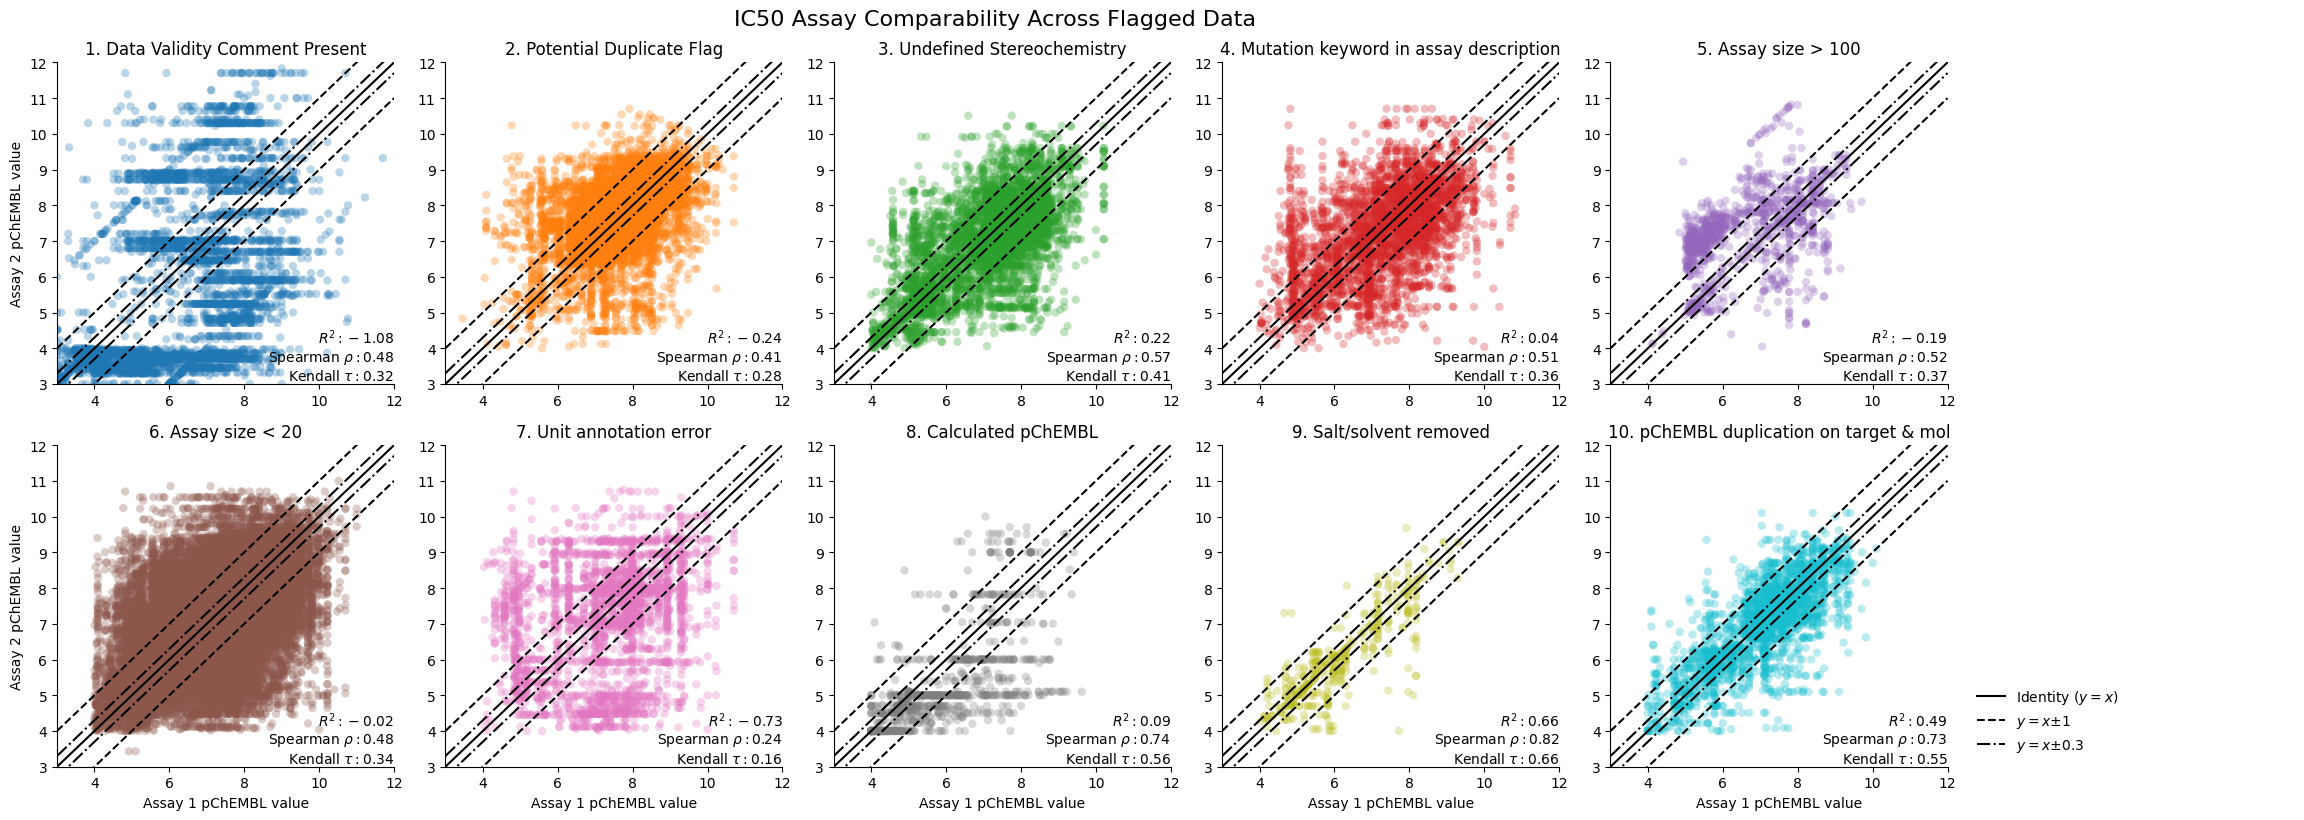

In [12]:
processing_comments = [
    "Calculated pChEMBL",
    "Salt/solvent removed",
    "pChEMBL duplication on target & mol",
]

colors = [tuple([*col] + [1]) for col in get_cmap("tab10").colors]

fig, axs = plt.subplots(2, 5, figsize=(20, 8))

observations = [*list(all_comments.values())]

for idx, color, obs, ax in zip(range(1, 11), colors, observations, axs.flatten()):
    if obs == "":
        subset = exploded_subset.query('dropping_comment == "" & processing_comment == ""')
    else:
        if obs in processing_comments:
            subset = exploded_subset.query(
                f"processing_comment.str.contains('{obs}', regex=False)" "& dropping_comment == ''"
            )
        else:
            if obs != "Data Validity Comment Present":  # In this case, pChEMBL is always calculated
                subset = exploded_subset.query(
                    f"dropping_comment.str.contains('{obs}', regex=False) & processing_comment == ''"
                )
            else:
                subset = exploded_subset.query(f"dropping_comment.str.contains('{obs}', regex=False)")
    subset["pchembl_value_x"] = subset["pchembl_value_x"].astype(float)
    subset["pchembl_value_y"] = subset["pchembl_value_y"].astype(float)
    ax.scatter(
        subset["pchembl_value_x"],
        subset["pchembl_value_y"],
        alpha=0.3,
        edgecolors="none",
        label=obs,
        color=color,
    )
    ax.set_title(f"{idx}. {obs}")
    # ax.scatter(xp, yp, alpha=0.2, edgecolors="none")
    # Add labels to each line for the legend
    ax.plot((3, 12), (3, 12), "k-", label="Identity $(y=x)$")
    ax.plot((3, 12), (2, 11), "k--")
    ax.plot((3, 12), (4, 13), "k--", label="$y=x±1$")
    ax.plot((3, 12), (2.7, 11.7), "k-.")
    ax.plot((3, 12), (3.3, 12.3), "k-.", label="$y=x±0.3$")

    # ax.title(titl)
    ax.set_xlim(3, 12)
    ax.set_ylim(3, 12)
    # remove the upper and the right spines
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    xp = subset["pchembl_value_x"]
    yp = subset["pchembl_value_y"]
    try:
        r, p = stats.spearmanr(xp, yp)
        tau, tp = stats.kendalltau(xp, yp)
        r2 = r2_score(xp, yp)
    except ValueError:
        continue

    ax.text(
        1.0,
        0.175,
        rf"$R^2: {r2:.2f}$" + "\n" + rf"Spearman $\rho: {r:.2f}$" + "\n" + rf"Kendall $\tau: {tau:.2f}$",
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        # bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    if idx in [1, 6]:
        ax.set_ylabel("Assay 2 pChEMBL value")
    if idx in list(range(6, 11)):
        ax.set_xlabel("Assay 1 pChEMBL value")

    if idx == 10:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[1:],
            labels[1:],
            title="",
            bbox_to_anchor=(1.05, 0, 1, 0.2),
            loc="lower left",
            mode="expand",
            frameon=False,
        )

fig.tight_layout()
fig.suptitle("IC50 Assay Comparability Across Flagged Data", fontsize=16, y=1.02)
fig.savefig("IC50_qualityFilters_str_contains.png", dpi=300, bbox_inches="tight", transparent=True)

/tmp/ipykernel_525121/333200826.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["pchembl_value_x"] = subset["pchembl_value_x"].astype(float)
/tmp/ipykernel_525121/333200826.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["pchembl_value_y"] = subset["pchembl_value_y"].astype(float)


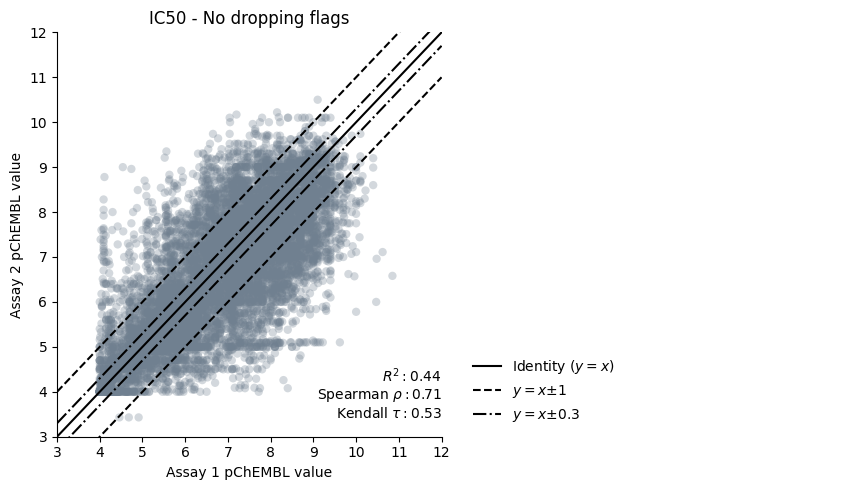

In [13]:
from typing import Tuple
import matplotlib


def plot_subset(
    subset: pd.DataFrame, title: str = ""
) -> Tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]:
    fig, ax = plt.subplots(figsize=(5, 5))
    subset["pchembl_value_x"] = subset["pchembl_value_x"].astype(float)
    subset["pchembl_value_y"] = subset["pchembl_value_y"].astype(float)
    ax.scatter(
        subset["pchembl_value_x"],
        subset["pchembl_value_y"],
        alpha=0.3,
        edgecolors="none",
        label=obs,
        color="slategray",
    )
    ax.set_title(title)
    # ax.scatter(xp, yp, alpha=0.2, edgecolors="none")
    # Add labels to each line for the legend
    ax.plot((3, 12), (3, 12), "k-", label="Identity $(y=x)$")
    ax.plot((3, 12), (2, 11), "k--")
    ax.plot((3, 12), (4, 13), "k--", label="$y=x±1$")
    ax.plot((3, 12), (2.7, 11.7), "k-.")
    ax.plot((3, 12), (3.3, 12.3), "k-.", label="$y=x±0.3$")

    # ax.title(titl)
    ax.set_xlim(3, 12)
    ax.set_ylim(3, 12)
    # remove the upper and the right spines
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    xp = subset["pchembl_value_x"]
    yp = subset["pchembl_value_y"]

    r, p = stats.spearmanr(xp, yp)
    tau, tp = stats.kendalltau(xp, yp)
    r2 = r2_score(xp, yp)

    ax.text(
        1.0,
        0.175,
        rf"$R^2: {r2:.2f}$" + "\n" + rf"Spearman $\rho: {r:.2f}$" + "\n" + rf"Kendall $\tau: {tau:.2f}$",
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        # bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_ylabel("Assay 2 pChEMBL value")
    ax.set_xlabel("Assay 1 pChEMBL value")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[1:],
        labels[1:],
        title="",
        bbox_to_anchor=(1.05, 0, 1, 0.2),
        loc="lower left",
        mode="expand",
        frameon=False,
    )
    fig.tight_layout()

    return fig, ax


subset = exploded_subset.query('dropping_comment == ""')
fig, ax = plot_subset(subset, title="IC50 - No dropping flags")
fig.savefig("IC50_allFiltered.png", dpi=300, bbox_inches="tight", transparent=True)

# TODO:
- Take a look at the influence of `PAINS`
- Remove some big molecules that are in the IC50 dataset (make sure they're druglike)
- Add the same analysis for the `Ki` dataset